“In this lab, I built and trained an LSTM-based model for text classification. I performed tokenization, padding, and trained the model using an embedding layer followed by LSTM. I also tested the model on new sentences. Additionally, I studied the concept of Sequence-to-Sequence models used for tasks like translation.”


##

🧠 Seq2Seq Architecture

👉 Two parts:

Encoder
Reads input sequence
Converts to context vector
Decoder
Generates output sequence

❓ How to improve model?

👉 Say:

Increase dataset size
 #
Use pretrained embeddings (GloVe)
#
Use Bidirectional LSTM
#
Tune hyperparameters

A Bidirectional LSTM means:

The model reads the sequence in both directions:
Left → Right (normal)
Right → Left (reverse)
🧠 Why this helps

In language, meaning depends on both past and future words.

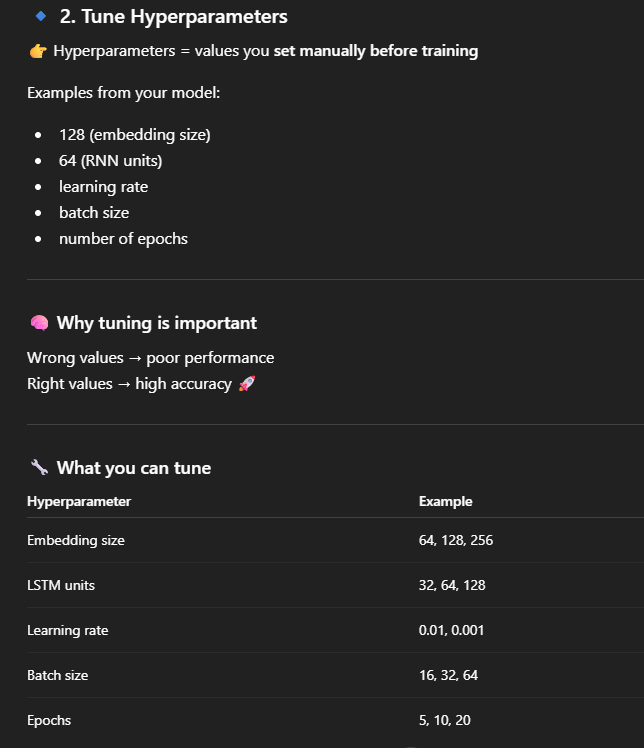

🔥 8. SEQ2SEQ QUESTIONS (VERY IMPORTANT)
❓ What is Seq2Seq?

👉 Input sequence → Output sequence

❓ Where used?

👉 Translation, chatbot, summarization

❓ Why LSTM used in Seq2Seq?

👉 Maintains long sequence memory

❓ What is encoder?

👉 Converts input → context vector

❓ What is decoder?

👉 Generates output from context

❓ Limitation of basic Seq2Seq?

👉 Fixed context vector → loses information

❓ Solution?

👉 Attention mechanism 🔥

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

In [ ]:
texts = [
    "I love this product",
    "This is a bad movie",
    "Excellent book",
    "Worst experience ever",
    "I feel great",
    "I hate it",
    "I hate this movie but ending is good",  # mixed sentiment
    "The movie was boring but visuals were amazing"
]

labels = [1, 0, 1, 0, 1, 0, 1, 1]  # 1 = positive, 0 = negative

In [ ]:
max_words = 1000
max_len = 15

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

print("Example padded sequence:\n", padded_sequences[6])

Example padded sequence:
 [ 2  6  3  4  7 20  5 21  0  0  0  0  0  0  0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, labels, test_size=0.25, random_state=42
)

Tokenization = text → numbers (basic level)
#
Embedding = converting those numbers into meaningful vectors
#
Why embedding?
Captures meaning of words
Similar words → similar vectors

In [ ]:
embedding_dim = 50

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary classification
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train, np.array(y_train),
    epochs=20,
    batch_size=2,
    validation_data=(X_test, np.array(y_test))
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.6667 - loss: 0.6894 - val_accuracy: 0.0000e+00 - val_loss: 0.7277
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8333 - loss: 0.6557 - val_accuracy: 0.0000e+00 - val_loss: 0.7834
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8333 - loss: 0.6452 - val_accuracy: 0.0000e+00 - val_loss: 0.8510
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8333 - loss: 0.5942 - val_accuracy: 0.0000e+00 - val_loss: 0.9327
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8333 - loss: 0.5924 - val_accuracy: 0.0000e+00 - val_loss: 1.0533
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8333 - loss: 0.5529 - val_accuracy: 0.0000e+00 - val_loss: 1.1491
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8333 - loss: 0.5584 - val_accuracy: 0.0000e+00 - val_loss: 1.2725
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8333 - loss: 0.4393 - val_accurac

In [ ]:
loss, accuracy = lstm_model.evaluate(X_test, np.array(y_test))
#print(f"Test Accuracy: {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.0000e+00 - loss: 2.0534


In [ ]:
new_texts = [
    "I hate this movie but the ending is good",
    "Absolutely loved the story and characters"
]

seq = tokenizer.texts_to_sequences(new_texts)
padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')
predictions = lstm_model.predict(padded_seq)

for text, pred in zip(new_texts, predictions):
    sentiment = "Positive" if pred[0] > 0.5 else "Negative"
    print(f"Text: {text}\nPredicted sentiment: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Text: I hate this movie but the ending is good
Predicted sentiment: Positive

Text: Absolutely loved the story and characters
Predicted sentiment: Positive

